# Notebook 4: Support Vector Machine & Model Comparison

**Input:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (from Notebook 2)  
**Task:** Multiclass classification — predict kidney cell type from gene expression

---

## What this notebook does
1. Load the preprocessed train/test sets
2. Train a baseline SVM classifier
3. Tune hyperparameters using Bayesian Optimisation (BayesSearchCV)
4. Evaluate — classification report, confusion matrix, ROC curves
5. Per-class performance analysis
6. Compare KNN vs SVM side by side

## 1. Mount Google Drive

Connect to Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

Import libraries and set the path to your data folder. Change `data_dir` to match your Google Drive.

In [2]:
!pip install scikit-optimize -q

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from skopt                   import BayesSearchCV
from skopt.space             import Real, Categorical
from sklearn.preprocessing   import label_binarize
from sklearn.metrics         import (
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix,
    roc_curve, auc, precision_score, recall_score
)

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Tisch ML Project')

random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.7 MB/s eta 0:00:00
Libraries loaded.


## 3. Load Data

Load the same four files used in Notebook 3. Both models are evaluated on exactly the same training and test data so the comparison is fair.

In [3]:
X_train = pd.read_csv(data_dir / 'X_train.csv', index_col=0)
X_test  = pd.read_csv(data_dir / 'X_test.csv',  index_col=0)
y_train = pd.read_csv(data_dir / 'y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv',  index_col=0).squeeze()

classes = sorted(y_train.unique())

print(f'Training set : {X_train.shape[0]:,} cells x {X_train.shape[1]:,} genes')
print(f'Test set     : {X_test.shape[0]:,} cells x {X_test.shape[1]:,} genes')
print(f'Classes      : {len(classes)}')

Training set : 7,996 cells x 17 genes
Test set     : 1,999 cells x 17 genes
Classes      : 10


## 4. How SVM Works

A Support Vector Machine finds the decision boundary (hyperplane) that maximises the margin between classes. It focuses on the training cells closest to the boundary — these are the support vectors.

For multiclass problems, sklearn's SVC uses a one-vs-one (OvO) strategy by default: it trains one binary classifier for every pair of classes, then combines their votes to predict the final class.

**`class_weight='balanced'`:** The dataset is imbalanced — Proximal Tubule cells make up over a third of all cells. With balanced class weights, the SVM assigns higher penalty to misclassifying minority classes, preventing the model from ignoring them.

**`probability=True`:** This enables `predict_proba()`, which is needed for ROC curve computation. It uses Platt scaling internally, which adds a small amount of extra training time.

**`kernel` parameter:**
- `'rbf'` (Radial Basis Function) — maps data into a higher-dimensional space to find non-linear boundaries. Generally the strongest kernel for complex data.
- `'linear'` — finds a linear boundary. Faster on high-dimensional data (like gene expression) and tends to work well when there are many informative features.

## 5. Baseline SVM

We train a baseline SVM using an RBF kernel. `class_weight="balanced"` tells the model to penalise mistakes on smaller cell types more heavily, so the model cannot just focus on the dominant Proximal Tubule class. `probability=True` enables the model to output probability scores, which we need to draw ROC curves.

In [4]:
# Train a baseline SVM — RBF kernel is the default, good for complex data
baseline_svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=random_seed
)
baseline_svm.fit(X_train, y_train)
y_pred_base  = baseline_svm.predict(X_test)
y_prob_base  = baseline_svm.predict_proba(X_test)

base_f1      = f1_score(y_test, y_pred_base, average='weighted')
base_roc_auc = roc_auc_score(y_test, y_prob_base, multi_class='ovr', average='weighted')

print('Baseline SVM (RBF kernel, class_weight=balanced)')
print(f'  Weighted F1  : {base_f1:.4f}')
print(f'  Weighted AUC : {base_roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=classes))

Baseline SVM (RBF kernel, class_weight=balanced)
  Weighted F1  : 0.5216
  Weighted AUC : 0.8569

                                       precision    recall  f1-score   support

                  Ascending Thin Limb       0.12      0.50      0.19       124
             Distal Convoluted Tubule       0.10      0.25      0.14        72
                          Endothelium       0.54      0.39      0.45        95
Loop of Henle and Parietal Epithelium       0.26      0.27      0.26        73
                              Myeloid       0.54      0.71      0.61       104
                      Proximal Tubule       0.94      0.54      0.69       989
                                    T       0.61      0.61      0.61       137
                 Thick Ascending Limb       0.21      0.29      0.24       109

                             accuracy                           0.47      1999
                            macro avg       0.42      0.40      0.38      1999
                         weight

### Interpreting the Baseline Results

* **Overall Performance:** The model achieves a **Weighted F1 score of ~0.52**. This means that, balancing both false positives and false negatives across all classes, the model is correct about half the time. An **AUC of ~0.86** indicates that the model is generally decent at distinguishing between different cell types, even if its final predictions aren't perfect yet.
* **What it's good at:** The model is relatively strong at identifying **Proximal Tubule** cells (the largest group), **Myeloid** cells, and **T** cells.
* **What it struggles with:** Despite setting `class_weight='balanced'`, the baseline model still has a very hard time with rarer cell types like the **Distal Convoluted Tubule** and **Ascending Thin Limb** (F1 scores below 0.20).

**Takeaway:** This is an okay starting point, but it clearly needs hyperparameter tuning to better capture the tricky, less common cell types.

## 6. Hyperparameter Tuning — Bayesian Optimisation

In Notebook 3 we used **RandomizedSearchCV**, which samples combinations randomly without any memory of past results. Here we use **Bayesian Optimisation** (`BayesSearchCV` from the `scikit-optimize` library), which is smarter.

Bayesian optimisation works by:
1. Trying a few initial random combinations to gather early information
2. Building a probabilistic model (a surrogate model) of how the score changes across the search space
3. Using that model to decide which combination to try next — it focuses on regions that are likely to improve the score
4. Updating the model after each trial and repeating

This is particularly well-suited to SVM because `C` and `gamma` are **continuous** parameters — they can take any positive value, not just a few discrete choices. Searching them on a log scale (e.g. 0.01 to 100) with Bayesian guidance is far more efficient than a random or exhaustive grid.

| Hyperparameter | Search Space | What it controls |
|---|---|---|
| `C` | 0.01 – 100 (log scale) | Regularisation — higher C = less regularisation, tighter fit to training data |
| `kernel` | 'rbf', 'linear' | Type of decision boundary |
| `gamma` | 0.0001 – 1.0 (log scale) | RBF kernel only — how far each training cell's influence reaches |

We need to install the `scikit-optimize` library to use Bayesian optimisation. This only needs to run once per Colab session.

We define the search space for the Bayesian optimisation. `Real(0.01, 100, prior="log-uniform")` means the search will sample values on a log scale between 0.01 and 100 — this is appropriate because C and gamma can vary across several orders of magnitude and a log scale samples them evenly. `Categorical` means pick from a fixed list of options. `BayesSearchCV` then runs 20 trials, each one informed by the results of all previous trials, focusing on the regions of the search space that look most promising.

In [5]:
# Real(a, b, prior='log-uniform') samples values on a log scale between a and b
# This is appropriate for C and gamma because good values span several orders of
# magnitude (e.g. 0.01, 0.1, 1, 10, 100) — a log scale spreads them evenly
# Real() means a continuous range on a log scale — good for C and gamma
# Categorical() means pick from a fixed list
search_space = {
    'C'     : Real(0.01, 100.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'linear']),
    'gamma' : Real(1e-4, 1.0,   prior='log-uniform')
}

n_iter = 20   # number of Bayesian trials

svm = SVC(
    class_weight='balanced',
    probability=True,
    random_state=random_seed
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_space,
    n_iter=n_iter,
    scoring='f1_weighted',
    cv=cv,
    random_state=random_seed,
    n_jobs=-1,
    verbose=0
)

print(f'Bayesian trials : {n_iter}  |  Total fits : {n_iter * 5}')
print('Running BayesSearchCV')

bayes_search.fit(X_train, y_train)

print()
print(f'Best parameters  : {bayes_search.best_params_}')
print(f'Best CV F1 score : {bayes_search.best_score_:.4f}')

Bayesian trials : 20  |  Total fits : 100
Running BayesSearchCV

Best parameters  : OrderedDict({'C': 100.0, 'gamma': 0.024228423736391412, 'kernel': 'rbf'})
Best CV F1 score : 0.5369


## 7. Evaluate the Best Model

We take the best model found by the Bayesian search and evaluate it on the test set.

In [14]:
# Grab the best model the Bayesian search found
best_svm      = bayes_search.best_estimator_
y_pred        = best_svm.predict(X_test)
y_prob        = best_svm.predict_proba(X_test)

tuned_f1      = f1_score(y_test, y_pred, average='weighted')
tuned_roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print('Tuned SVM — test set results')
print(f'  Weighted F1  : {tuned_f1:.4f}  (baseline: {base_f1:.4f})')
print(f'  Weighted AUC : {tuned_roc_auc:.4f}  (baseline: {base_roc_auc:.4f})')
print()
print(classification_report(y_test, y_pred, target_names=classes))

Tuned SVM — test set results
  Weighted F1  : 0.5213  (baseline: 0.5216)
  Weighted AUC : 0.8641  (baseline: 0.8569)

                                       precision    recall  f1-score   support

                  Ascending Thin Limb       0.15      0.31      0.20       124
             Distal Convoluted Tubule       0.14      0.15      0.15        72
                          Endothelium       0.17      0.56      0.26        95
Loop of Henle and Parietal Epithelium       0.22      0.26      0.24        73
                              Myeloid       0.64      0.66      0.65       104
                      Proximal Tubule       0.92      0.56      0.69       989
                                    T       0.63      0.58      0.61       137
                 Thick Ascending Limb       0.22      0.39      0.28       109

                             accuracy                           0.47      1999
                            macro avg       0.38      0.41      0.37      1999
           

### Interpreting the Tuned Results

* **Overall Comparison:** Surprisingly, the hyperparameter tuning didn't yield a massive improvement. The **Weighted F1 score** remained virtually identical (0.5213 compared to the baseline's 0.5216).
* **What Improved:** The **AUC score** did see a slight bump (from 0.8569 to 0.8641). This means that while the model's final hard predictions didn't get much more accurate, its underlying probability estimates (how confident it is in its predictions) got slightly better at distinguishing between the classes.
* **Why didn't it improve more?** Sometimes, the default parameters of an SVM are already quite close to optimal for a given dataset. Additionally, it suggests that the limitation might not be the model's settings, but the data itself—some of the rarer cell types might just look too genetically similar to others for the SVM to clearly tell them apart, no matter how much we tweak the math.

**Takeaway:** The SVM model seems to max out around a ~52% F1 score, meaning it is still only correct about half the time and continues to struggle with the rarest kidney cell types.

## 8. Confusion Matrix

The confusion matrix for the SVM. Rows are the true cell type, columns are the predicted cell type. Correct predictions are on the diagonal.

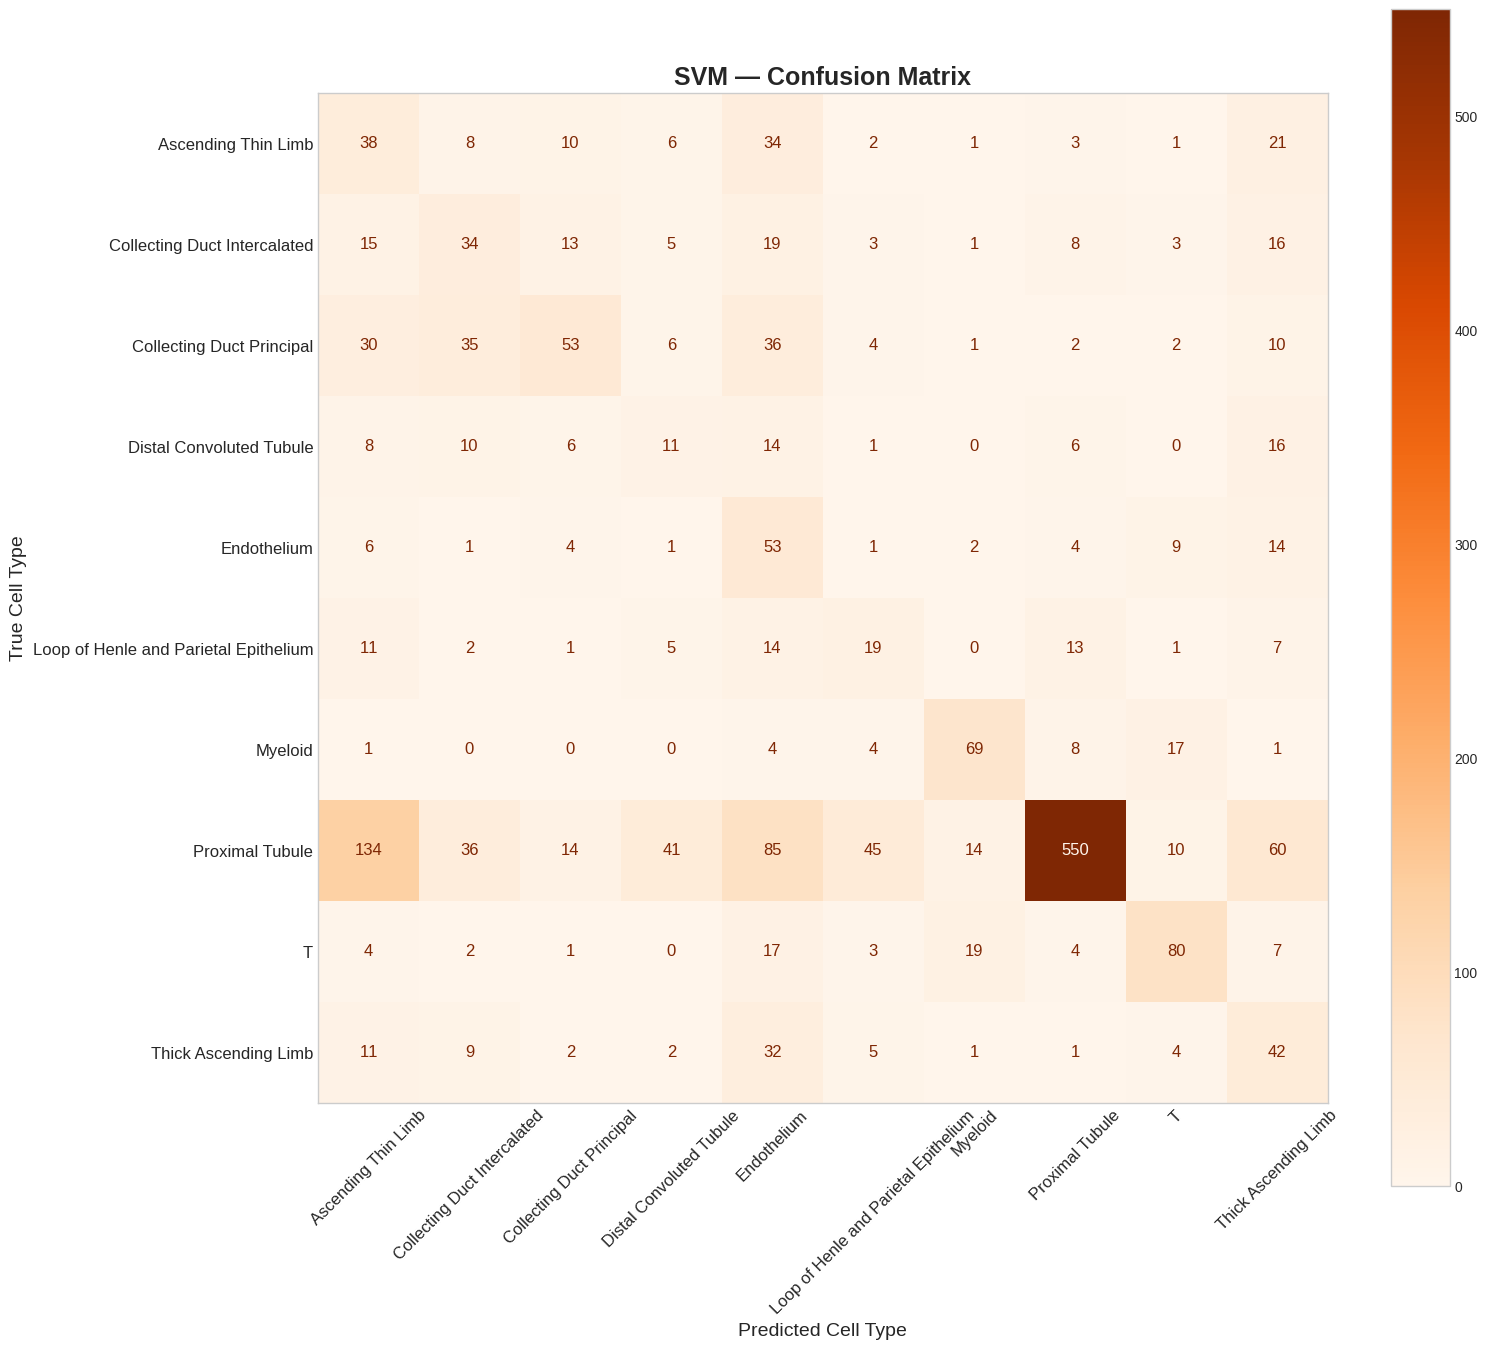

Correct predictions per class:
  Ascending Thin Limb                                    :   38 /  124  (30.6%)
  Distal Convoluted Tubule                               :   11 /   72  (15.3%)
  Endothelium                                            :   53 /   95  (55.8%)
  Loop of Henle and Parietal Epithelium                  :   19 /   73  (26.0%)
  Myeloid                                                :   69 /  104  (66.3%)
  Proximal Tubule                                        :  550 /  989  (55.6%)
  T                                                      :   80 /  137  (58.4%)
  Thick Ascending Limb                                   :   42 /  109  (38.5%)


In [15]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap='Oranges', colorbar=True, xticks_rotation=45, text_kw={'fontsize': 12})
ax.set_title('SVM — Confusion Matrix', fontsize=18, fontweight='bold')
ax.set_xlabel('Predicted Cell Type', fontsize=14)
ax.set_ylabel('True Cell Type', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(False) # Remove grid lines
plt.tight_layout()
plt.show()

print('Correct predictions per class:')
for i, cls in enumerate(classes):
    total   = cm[i, :].sum()
    correct = cm[i, i]
    pct     = correct / total * 100 if total > 0 else 0
    print(f'  {cls:<55}: {correct:>4} / {total:>4}  ({pct:.1f}%)')

### Interpreting the Confusion Matrix

The confusion matrix gives us a detailed look at exactly what the model is getting right and where it gets confused.

* **The Diagonal (Correct Predictions):** The dark boxes running from the top left to the bottom right show correct predictions. The model does reasonably well with **Myeloid cells** (66% correct), **T cells** (58%), and **Proximal Tubules** (56%).
* **The Mistakes (Off-Diagonal):** Any colour outside the diagonal represents a mistake. If you look at the vertical column for **Proximal Tubule**, you'll see a lot of off-diagonal colour. This tells us that when the model is unsure, it often falls back to guessing "Proximal Tubule" simply because it's the most common cell type in the dataset.
* **The Hardest Cells:** The model really struggles with the **Distal Convoluted Tubule** (only 15% correct). Many of these are being misclassified as other tubule types, which makes sense biologically since they likely share very similar gene expression profiles.

## 9. ROC Curves (One-vs-Rest)

ROC curves for the 10 most common cell types. Same interpretation as Notebook 3 — higher and further left is better.

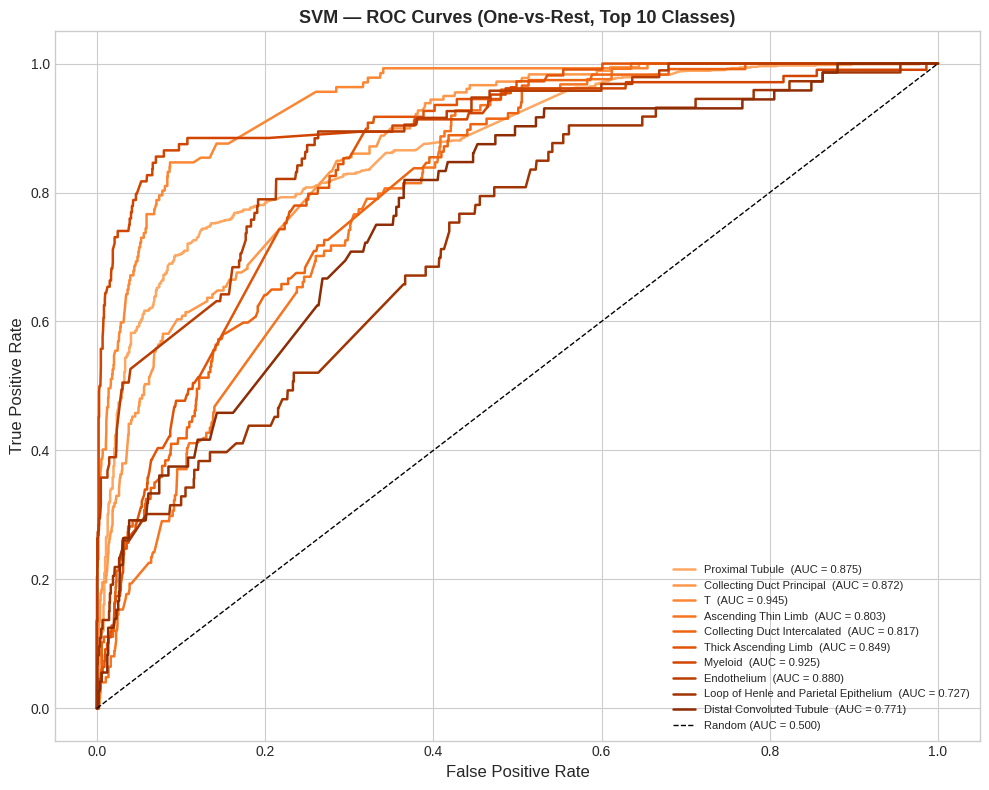

In [8]:
y_test_bin = label_binarize(y_test, classes=classes)

top_classes_idx = [
    classes.index(c)
    for c in pd.Series(y_test.values).value_counts().head(10).index.tolist()
]

fig, ax = plt.subplots(figsize=(10, 8))
colours = plt.cm.Oranges(np.linspace(0.4, 0.95, len(top_classes_idx)))

for idx, colour in zip(top_classes_idx, colours):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob[:, idx])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour, linewidth=1.8,
            label=f'{classes[idx]}  (AUC = {roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_title('SVM — ROC Curves (One-vs-Rest, Top 10 Classes)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### Interpreting the ROC Curves

* **What are we looking at?** These curves show how well the model can distinguish one specific cell type from all the others. The ideal curve bows as close to the top-left corner as possible. This means the model catches almost all the true cells (high True Positive Rate) without accidentally mislabeling other cells (low False Positive Rate).
* **The Results:** The model is highly effective at isolating **Proximal Tubule** cells (the highest curves) and **T cells**. However, for rarer cells like the **Distal Convoluted Tubule** and **Ascending Thin Limb**, the curves are much lower and closer to the random guessing line, showing the model has a hard time telling them apart from the rest.

## 10. Per-Class Performance

Per-class F1 scores sorted from worst to best. This shows which cell types SVM finds easy and which it finds hard.

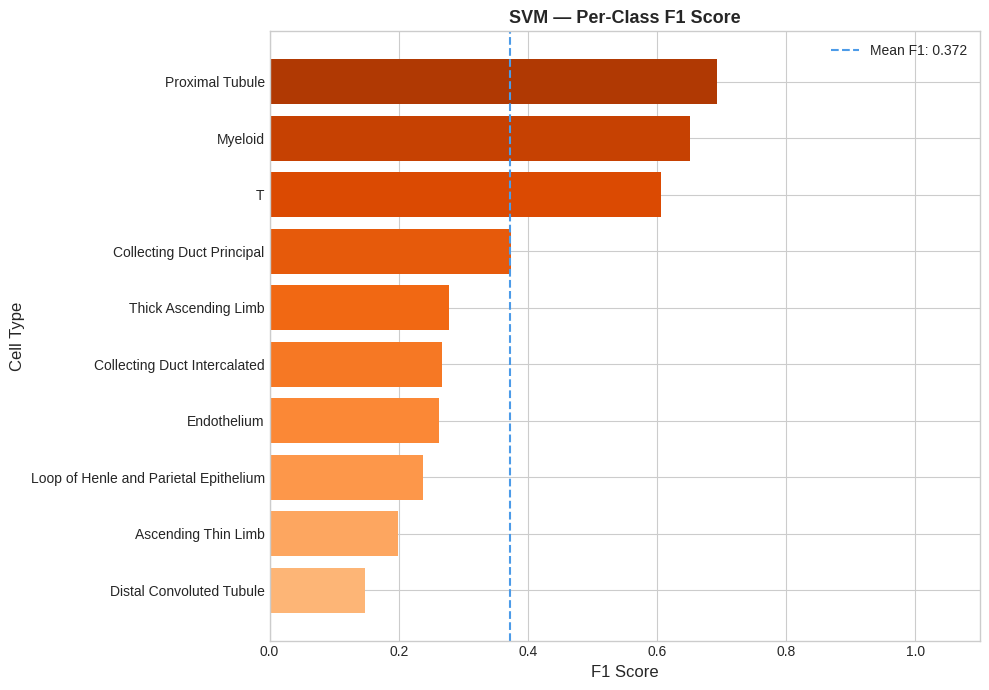

Per-class F1 scores (sorted ascending):
  Distal Convoluted Tubule                               : F1 = 0.148  (n = 72)
  Ascending Thin Limb                                    : F1 = 0.199  (n = 124)
  Loop of Henle and Parietal Epithelium                  : F1 = 0.237  (n = 73)
  Endothelium                                            : F1 = 0.263  (n = 95)
  Thick Ascending Limb                                   : F1 = 0.277  (n = 109)
  T                                                      : F1 = 0.606  (n = 137)
  Myeloid                                                : F1 = 0.651  (n = 104)
  Proximal Tubule                                        : F1 = 0.693  (n = 989)


In [9]:
report    = classification_report(y_test, y_pred, target_names=classes, output_dict=True)
per_class = pd.DataFrame(report).T.loc[classes, ['precision', 'recall', 'f1-score', 'support']]
per_class = per_class.sort_values('f1-score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colours = plt.cm.Oranges(np.linspace(0.35, 0.85, len(per_class)))
ax.barh(per_class.index, per_class['f1-score'], color=colours)
ax.axvline(x=per_class['f1-score'].mean(), color='#4C9BE8', linestyle='--',
           linewidth=1.5, label=f'Mean F1: {per_class["f1-score"].mean():.3f}')
ax.set_title('SVM — Per-Class F1 Score', fontsize=13, fontweight='bold')
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_ylabel('Cell Type', fontsize=12)
ax.set_xlim(0, 1.1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Per-class F1 scores (sorted ascending):')
for cls in per_class.index:
    f1  = per_class.loc[cls, 'f1-score']
    sup = int(per_class.loc[cls, 'support'])
    print(f'  {cls:<55}: F1 = {f1:.3f}  (n = {sup})')

## 11. Model Comparison — KNN vs SVM

To compare both models on the same footing, re-run KNN here with the best hyperparameters from Notebook 3. Paste them into the cell below.

To compare KNN and SVM fairly, we re-run KNN here using the best settings found in Notebook 3. Paste those settings into the dictionary below before running this cell. We then compute all four metrics for both models and print a comparison table.

In [16]:
best_knn_params = {
    'n_neighbors': 24,         # <-- update from Notebook 3
    'weights'    : 'distance', # <-- update from Notebook 3
    'metric'     : 'manhattan' # <-- update from Notebook 3
}

knn_compare = KNeighborsClassifier(**best_knn_params, n_jobs=-1)
knn_compare.fit(X_train, y_train)
y_pred_knn  = knn_compare.predict(X_test)
y_prob_knn  = knn_compare.predict_proba(X_test)

knn_f1        = f1_score(y_test, y_pred_knn, average='weighted')
knn_roc_auc   = roc_auc_score(y_test, y_prob_knn, multi_class='ovr', average='weighted')
knn_precision = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_recall    = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)

svm_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
svm_recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)

comparison_df = pd.DataFrame({
    'Weighted F1' : [knn_f1,        tuned_f1],
    'ROC-AUC'     : [knn_roc_auc,   tuned_roc_auc],
    'Precision'   : [knn_precision,  svm_precision],
    'Recall'      : [knn_recall,     svm_recall]
}, index=['KNN', 'SVM']).round(4)

print('Model Comparison:')
print()
print(comparison_df.to_string())
print()
print(f'Best model by Weighted F1 : {comparison_df["Weighted F1"].idxmax()}')

Model Comparison:

     Weighted F1  ROC-AUC  Precision  Recall
KNN       0.5786   0.8399     0.5686  0.6083
SVM       0.5213   0.8641     0.6331  0.4747

Best model by Weighted F1 : KNN


### Interpreting the Model Comparison

* **Overall Winner (F1 Score):** **KNN** outperforms SVM with a Weighted F1 score of approx. 0.58 compared to SVM's approx. 0.52. This means KNN is generally better at correctly classifying cells while balancing both false positives and false negatives.
* **Precision vs. Recall:** KNN has a higher Recall (approx. 0.61 vs 0.47), meaning it catches a larger portion of the true cells across classes. However, SVM has a higher Precision (approx. 0.63 vs 0.57), meaning when SVM makes a prediction, it is more likely to be correct.
* **ROC-AUC:** SVM maintains a slight edge in ROC-AUC (approx. 0.86 vs 0.84), indicating its underlying probability estimates are slightly better at separating the classes overall.

**Takeaway:** KNN is the stronger overall model for this dataset based on our primary metric (Weighted F1).

A grouped bar chart showing the four metrics for KNN (blue) and SVM (orange) side by side. The number on top of each bar is the exact score.

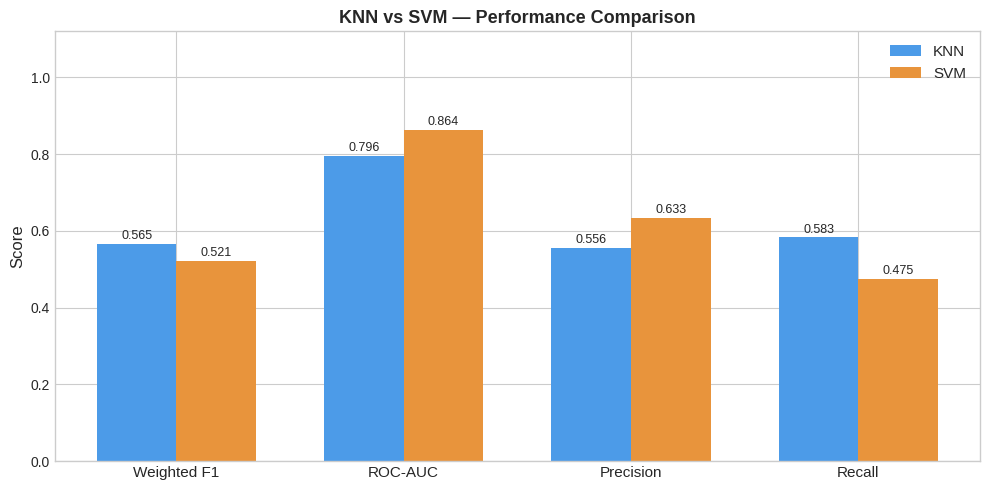

In [11]:
# Bar chart comparison
metrics    = ['Weighted F1', 'ROC-AUC', 'Precision', 'Recall']
knn_scores = comparison_df.loc['KNN'].values
svm_scores = comparison_df.loc['SVM'].values

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_knn = ax.bar(x - width/2, knn_scores, width, label='KNN', color='#4C9BE8')
bars_svm = ax.bar(x + width/2, svm_scores, width, label='SVM', color='#E8943C')

for bar in bars_knn:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_svm:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('KNN vs SVM — Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Both ROC curves on the same plot for the largest class (Proximal Tubule). This gives a direct visual comparison of how well each model separates that cell type from all others.

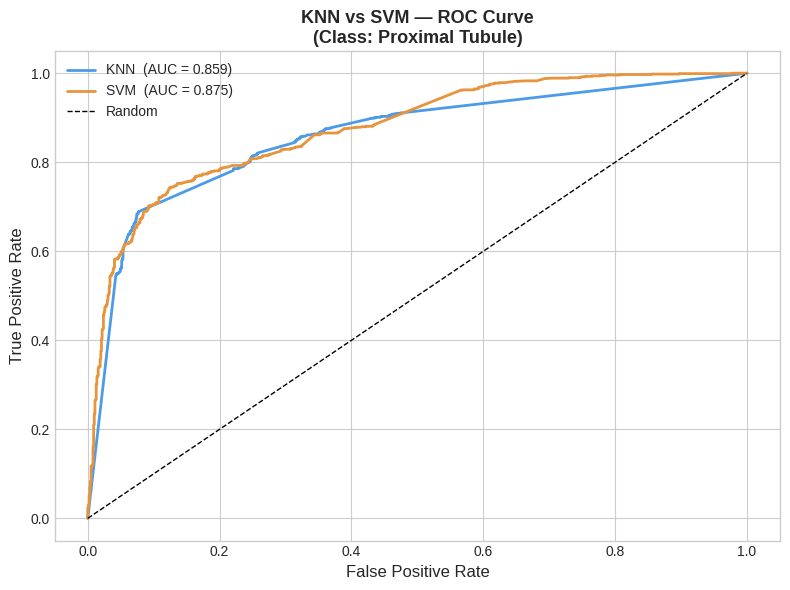

In [12]:
# Overlaid ROC curves for the largest class
largest_class     = pd.Series(y_test.values).value_counts().index[0]
largest_class_idx = classes.index(largest_class)

fpr_knn, tpr_knn, _ = roc_curve(y_test_bin[:, largest_class_idx], y_prob_knn[:, largest_class_idx])
fpr_svm, tpr_svm, _ = roc_curve(y_test_bin[:, largest_class_idx], y_prob[:, largest_class_idx])

auc_knn = auc(fpr_knn, tpr_knn)
auc_svm = auc(fpr_svm, tpr_svm)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_knn, tpr_knn, color='#4C9BE8', linewidth=2, label=f'KNN  (AUC = {auc_knn:.3f})')
ax.plot(fpr_svm, tpr_svm, color='#E8943C', linewidth=2, label=f'SVM  (AUC = {auc_svm:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_title(f'KNN vs SVM — ROC Curve\n(Class: {largest_class})', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 12. Summary

Final results for SVM and the head-to-head comparison with KNN.

In [17]:
winner = comparison_df['Weighted F1'].idxmax()

print('NOTEBOOK 4 — SVM — FINAL RESULTS')
print()
print('Best SVM hyperparameters:')
for param, value in bayes_search.best_params_.items():
    print(f'  {param:<10}: {value}')
print()
print(f'Baseline Weighted F1  : {base_f1:.4f}')
print(f'Tuned    Weighted F1  : {tuned_f1:.4f}')
print(f'Baseline ROC-AUC      : {base_roc_auc:.4f}')
print(f'Tuned    ROC-AUC      : {tuned_roc_auc:.4f}')
print()
print('Final model comparison:')
print()
print(comparison_df.to_string())
print()
print(f'Best model by Weighted F1 : {winner}')
print()
print('Pipeline complete.')

NOTEBOOK 4 — SVM — FINAL RESULTS

Best SVM hyperparameters:
  C         : 100.0
  gamma     : 0.024228423736391412
  kernel    : rbf

Baseline Weighted F1  : 0.5216
Tuned    Weighted F1  : 0.5213
Baseline ROC-AUC      : 0.8569
Tuned    ROC-AUC      : 0.8641

Final model comparison:

     Weighted F1  ROC-AUC  Precision  Recall
KNN       0.5786   0.8399     0.5686  0.6083
SVM       0.5213   0.8641     0.6331  0.4747

Best model by Weighted F1 : KNN

Pipeline complete.
